Импорт библиотек

In [2]:
# -*- coding: utf-8 -*-
"""
Модуль ядра системы мониторинга состояния водителя (MVP).

Реализует:
  - Захват видеопотока с USB-камеры
  - Извлечение лицевых метрик (MAR, EAR, расстояние, yaw, roll)
  - Четыре системы политопной детекции:
      1. Зевок: MAR + расстояние нос-подбородок
      2. Сонливость: EAR < порог
      3. Отвлечение внимания: |yaw| > 30°
      4. Наклон головы: |roll| > 20°
  - Расчет PERCLOS в скользящем окне 30 секунд
  - Оценку критичности состояния (NORMAL/WARNING/DANGER/CRITICAL)
  - Индивидуальную калибровку (30 секунд)
  - Сохранение данных в SQLite базу данных
  - Визуализацию с цветовой индикацией
  - Генерацию отчетов

Автор: Волков Д.В.
Версия: 2.0 (ВКР)
"""

import cv2
import numpy as np
import mediapipe as mp
import sqlite3
import json
import os
from datetime import datetime
from pathlib import Path
import time
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Библиотеки загружены")

Библиотеки загружены


Конфигурация системы

In [3]:
class SystemConfig:
    """
    Конфигурация системы мониторинга усталости.

    Загружает научные коэффициенты из JSON-файла.
    Содержит индексы ключевых точек MediaPipe и параметры систем.
    """

    COEFFICIENTS_PATH = "data/scientific_coefficients.json"
    DB_PATH = "driver_fatigue_monitoring.db"

    # Индексы точек MediaPipe для MAR (Dlib-стиль, 3 вертикальных замера)
    MAR_TOP_LEFT = 80
    MAR_BOTTOM_LEFT = 82
    MAR_TOP_CENTER = 13
    MAR_BOTTOM_CENTER = 14
    MAR_TOP_RIGHT = 312
    MAR_BOTTOM_RIGHT = 317
    MAR_LEFT_CORNER = 78
    MAR_RIGHT_CORNER = 308

    # Индексы точек для EAR
    LEFT_EYE_IDX = [362, 385, 387, 263, 373, 380]
    RIGHT_EYE_IDX = [33, 160, 158, 133, 153, 144]

    # Индексы для расстояния нос-подбородок
    NOSE_TIP_IDX = 1
    CHIN_IDX = 152
    LEFT_EYE_OUTER = 33
    RIGHT_EYE_OUTER = 263

    # Индексы для позы головы
    POSE_IDS = [1, 152, 33, 263, 61, 291]

    # 3D-модель для solvePnP
    FACE_3D = np.array([
        [0.0, 0.0, 0.0],
        [0.0, -330.0, -65.0],
        [-225.0, 170.0, -135.0],
        [225.0, 170.0, -135.0],
        [-150.0, -150.0, -125.0],
        [150.0, -150.0, -125.0]
    ], dtype=np.float64)

    # Параметры системы
    CALIBRATION_SECONDS = 30
    FPS_TARGET = 30

    # Окна политопов
    YAWN_WINDOW = 15         # 0.5 сек — зевок
    STATE_WINDOW = 60        # 2 сек — сонливость, отвлечение, наклон

    # Фиксированные пороги для позы головы
    YAW_THRESHOLD = 30.0     # градусов
    ROLL_THRESHOLD = 20.0    # градусов

    # Порог EAR (фиксированный коэффициент из литературы)
    K_EAR = 0.6

    def __init__(self):
        self.load_coefficients()

    def load_coefficients(self):
        """Загрузка научных коэффициентов из JSON файла."""
        if not os.path.exists(self.COEFFICIENTS_PATH):
            print(f"Внимание: файл {self.COEFFICIENTS_PATH} не найден.")
            print("Используются коэффициенты по умолчанию.")
            self.K_MAR = 7.26
            self.K_NOSE_CHIN = 1.38
            return

        with open(self.COEFFICIENTS_PATH, 'r', encoding='utf-8') as f:
            data = json.load(f)

        coefficients = data.get('coefficients', {})
        self.K_MAR = coefficients.get('K_mar', {}).get('value', 7.26)
        self.K_NOSE_CHIN = coefficients.get('K_nose_chin_distance', {}).get('value', 1.38)

        print(f"Коэффициенты загружены: K_MAR={self.K_MAR:.2f}, "
              f"K_NOSE_CHIN={self.K_NOSE_CHIN:.2f}")


config = SystemConfig()

Коэффициенты загружены: K_MAR=7.26, K_NOSE_CHIN=1.38


In [129]:
class FaceMetricsExtractor:
    """
    Извлечение геометрических метрик лица.

    Метрики:
      - MAR (Dlib-стиль, 3 вертикальных замера)
      - EAR (для левого и правого глаза)
      - Расстояние нос-подбородок (нормированное)
      - Yaw, Roll (поза головы)
    """

    def __init__(self, config):
        self.config = config
        self.mp_face_mesh = mp.solutions.face_mesh
        self.face_mesh = None

    def initialize(self):
        """Инициализация MediaPipe Face Mesh."""
        self.face_mesh = self.mp_face_mesh.FaceMesh(
            static_image_mode=False,
            max_num_faces=1,
            refine_landmarks=True,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )

    def release(self):
        """Освобождение ресурсов."""
        if self.face_mesh is not None:
            self.face_mesh.close()

    def compute_mar(self, landmarks, w, h):
        """
        Расчет MAR по Dlib-стилю с тремя вертикальными замерами.
        MAR = (|P80-P82| + |P13-P14| + |P312-P317|) / (3 * |P78-P308|)
        """
        def pt(idx):
            return np.array([landmarks[idx].x * w, landmarks[idx].y * h])

        v_left = np.linalg.norm(pt(self.config.MAR_TOP_LEFT) - pt(self.config.MAR_BOTTOM_LEFT))
        v_center = np.linalg.norm(pt(self.config.MAR_TOP_CENTER) - pt(self.config.MAR_BOTTOM_CENTER))
        v_right = np.linalg.norm(pt(self.config.MAR_TOP_RIGHT) - pt(self.config.MAR_BOTTOM_RIGHT))
        horizontal = np.linalg.norm(pt(self.config.MAR_LEFT_CORNER) - pt(self.config.MAR_RIGHT_CORNER))

        if horizontal < 1e-6:
            return 0.0
        return (v_left + v_center + v_right) / (3.0 * horizontal)

    def compute_ear(self, landmarks, eye_idx, w, h):
        """Расчет Eye Aspect Ratio для одного глаза."""
        pts = np.array([[landmarks[i].x * w, landmarks[i].y * h] for i in eye_idx])
        vertical = (np.linalg.norm(pts[1] - pts[5]) + np.linalg.norm(pts[2] - pts[4]))
        horizontal = 2.0 * np.linalg.norm(pts[0] - pts[3])
        return vertical / (horizontal + 1e-6)

    def compute_nose_chin(self, landmarks, w, h):
        """
        Расчет нормализованного расстояния нос-подбородок.
        
        """
        def pt(idx):
            return np.array([landmarks[idx].x * w, landmarks[idx].y * h])
        
        nose = pt(self.config.NOSE_TIP_IDX)
        chin = pt(self.config.CHIN_IDX)  # точка 152
        left_eye = pt(self.config.LEFT_EYE_OUTER)
        right_eye = pt(self.config.RIGHT_EYE_OUTER)
        
        absolute = np.linalg.norm(nose - chin)
        face_w = np.linalg.norm(left_eye - right_eye)
        
        return absolute / face_w if face_w > 0 else 0.85

    def get_head_pose(self, landmarks, h, w):
        """Оценка углов поворота головы (yaw, pitch, roll)."""
        pts_2d = np.array(
            [(landmarks[i].x * w, landmarks[i].y * h) for i in self.config.POSE_IDS],
            dtype=np.float64
        )
        focal = float(w)
        cam_mat = np.array([
            [focal, 0.0, float(w) / 2.0],
            [0.0, focal, float(h) / 2.0],
            [0.0, 0.0, 1.0]
        ], dtype=np.float64)
        dist = np.zeros((4, 1), dtype=np.float64)
        ok, rvec, _ = cv2.solvePnP(self.config.FACE_3D, pts_2d, cam_mat, dist)
        if not ok:
            return None, None, None
        rmat, _ = cv2.Rodrigues(rvec)
        angles, _, _, _, _, _ = cv2.RQDecomp3x3(rmat)
        return angles[1], angles[0], angles[2]  # yaw, pitch, roll


extractor = FaceMetricsExtractor(config)
print("FaceMetricsExtractor создан")

FaceMetricsExtractor создан


In [130]:
class Polytope1D:
    """
    Одномерный политоп для детекции превышения порога.

    Используется для:
      - Отвлечения внимания (|yaw| > порог, mode='above')
      - Наклона головы (|roll| > порог, mode='above')
      - Сонливости (EAR < порог, mode='below')

    Событие фиксируется, если ВСЕ кадры в окне удовлетворяют условию.
    """

    def __init__(self, window_size, threshold, mode='above'):
        """
        Аргументы:
            window_size: размер окна в кадрах
            threshold: пороговое значение
            mode: 'above' — значение >= порога, 'below' — значение < порога
        """
        self.window_size = window_size
        self.threshold = threshold
        self.mode = mode
        self.buffer = deque(maxlen=window_size)

    def add_frame(self, value):
        """Добавление значения в буфер."""
        self.buffer.append(value)

    def is_full(self):
        """Заполнено ли окно полностью."""
        return len(self.buffer) >= self.window_size

    def check(self):
        """
        Проверка условия для всего окна.
        Возвращает True, если все значения в окне удовлетворяют условию.
        """
        if not self.is_full():
            return False
        if self.mode == 'above':
            return min(self.buffer) >= self.threshold
        else:
            return max(self.buffer) < self.threshold


class Polytope2D:
    """
    Двумерный политоп для детекции зевка.

    Измерения:
      - MAR (открытость рта)
      - Расстояние нос-подбородок (опускание челюсти)

    Зевок фиксируется, если ОБА параметра >= порогов
    для ВСЕХ кадров в окне.
    """

    def __init__(self, window_size, mar_threshold, nose_chin_threshold):
        self.window_size = window_size
        self.mar_threshold = mar_threshold
        self.nose_chin_threshold = nose_chin_threshold
        self.mar_buffer = deque(maxlen=window_size)
        self.nose_chin_buffer = deque(maxlen=window_size)

    def add_frame(self, mar, nose_chin):
        """Добавление кадра в буферы."""
        self.mar_buffer.append(mar)
        self.nose_chin_buffer.append(nose_chin)

    def is_full(self):
        """Заполнено ли окно полностью."""
        return len(self.mar_buffer) >= self.window_size

    def check(self):
        """
        Проверка зевка: оба параметра >= порогов для ВСЕХ кадров в окне.
        """
        if not self.is_full():
            return False
        return (
            min(self.mar_buffer) >= self.mar_threshold and
            min(self.nose_chin_buffer) >= self.nose_chin_threshold
        )


print("Polytope1D, Polytope2D созданы")

Polytope1D, Polytope2D созданы


In [131]:
class PERCLOSCalculator:
    """
    Калькулятор метрики PERCLOS.

    PERCLOS — процент времени, в течение которого глаза были закрыты
    в скользящем окне заданной длительности.

    Пороги усталости:
      - normal: PERCLOS < 10%
      - light: 10% ≤ PERCLOS < 20%
      - medium: 20% ≤ PERCLOS < 28%
      - critical: PERCLOS ≥ 28% (с подтверждением ≥ 2 сек)
    """

    def __init__(self, window_seconds=30, fps=30):
        """
        Аргументы:
            window_seconds: размер скользящего окна в секундах
            fps: частота кадров
        """
        self.window_size = window_seconds * fps
        self.ear_threshold = None
        self.ear_history = deque(maxlen=self.window_size)
        self.closed_history = deque(maxlen=self.window_size)
        self.confirmed_critical = False
        self.critical_start_time = 0

    def set_ear_threshold(self, threshold):
        """Установить индивидуальный порог EAR."""
        self.ear_threshold = threshold

    def add_frame(self, ear_value):
        """
        Добавить кадр в историю.

        Аргументы:
            ear_value: текущее значение EAR
        """
        if self.ear_threshold is None:
            return

        is_closed = ear_value < self.ear_threshold
        self.ear_history.append(ear_value)
        self.closed_history.append(is_closed)

    def calculate(self):
        """
        Расчет текущего PERCLOS.

        Возвращает:
            perclos: процент кадров с закрытыми глазами (0-100%)
        """
        if len(self.closed_history) == 0:
            return 0.0
        return (sum(self.closed_history) / len(self.closed_history)) * 100

    def get_level(self):
        """
        Определение уровня усталости по PERCLOS.

        Возвращает:
            уровень: 'normal', 'light', 'medium', 'critical'
        """
        perclos = self.calculate()

        if perclos >= 28:
            current_time = time.time()
            if not self.confirmed_critical:
                self.confirmed_critical = True
                self.critical_start_time = current_time
                return 'medium'
            elif current_time - self.critical_start_time >= 2.0:
                return 'critical'
            else:
                return 'medium'
        else:
            self.confirmed_critical = False
            if perclos >= 20:
                return 'medium'
            elif perclos >= 10:
                return 'light'
            else:
                return 'normal'

    def reset(self):
        """Сброс истории (при новой калибровке)."""
        self.ear_history.clear()
        self.closed_history.clear()
        self.confirmed_critical = False


print("PERCLOSCalculator создан")

PERCLOSCalculator создан


In [132]:
class CriticalityEvaluator:
    """
    Оценка критичности состояния водителя.

    Анализирует сочетания событий от четырех систем детекции
    и PERCLOS для формирования интегральной оценки опасности.

    Уровни критичности:
      0 - NORMAL:    нет событий
      1 - WARNING:   одно событие (зевок ИЛИ отвлечение)
      2 - DANGER:    сонливость ИЛИ наклон ИЛИ зевок+отвлечение
      3 - CRITICAL:  два события одновременно ИЛИ PERCLOS≥28%

    Сообщения выводятся на английском языке для размещения
    в верхнем левом углу экрана, не перекрывая лицо.
    """

    def __init__(self):
        self.level = 0
        self.messages = []
        self.level_names = {0: 'NORMAL', 1: 'WARNING', 2: 'DANGER', 3: 'CRITICAL'}

    def evaluate(self, yawn_detected, drowsiness_detected,
                 distraction_detected, roll_detected, perclos_level):
        """
        Оценка критичности на основе флагов детекции и PERCLOS.

        Аргументы:
            yawn_detected: флаг зевка
            drowsiness_detected: флаг сонливости
            distraction_detected: флаг отвлечения
            roll_detected: флаг наклона
            perclos_level: уровень PERCLOS (normal/light/medium/critical)

        Возвращает:
            level: уровень критичности (0-3)
            messages: список сообщений для отображения
        """
        self.messages = []
        criticality_score = 0

        # Сбор активных событий
        if yawn_detected:
            self.messages.append("YAWN DETECTED")
            criticality_score += 1

        if drowsiness_detected:
            self.messages.append("DROWSINESS: eyes closed")
            criticality_score += 2

        if distraction_detected:
            self.messages.append("DISTRACTION: head turned")
            criticality_score += 1

        if roll_detected:
            self.messages.append("HEAD ROLL: head tilted")
            criticality_score += 2

        # PERCLOS
        if perclos_level == 'critical':
            self.messages.append("PERCLOS CRITICAL (>28%)")
            criticality_score = max(criticality_score, 3)
        elif perclos_level == 'medium':
            if "DROWSINESS" not in str(self.messages):
                self.messages.append("FATIGUE MEDIUM")
            criticality_score = max(criticality_score, 2)

        # Комбинации событий
        if yawn_detected and drowsiness_detected:
            self.messages.append("CRITICAL: yawn + drowsiness")
            criticality_score = max(criticality_score, 3)

        if distraction_detected and drowsiness_detected:
            self.messages.append("CRITICAL: distraction + drowsiness")
            criticality_score = max(criticality_score, 3)

        if roll_detected and drowsiness_detected:
            self.messages.append("CRITICAL: head roll + drowsiness")
            criticality_score = max(criticality_score, 3)

        # Определение уровня
        if criticality_score >= 3:
            self.level = 3
        elif criticality_score == 2:
            self.level = 2
        elif criticality_score == 1:
            self.level = 1
        else:
            self.level = 0
            if not self.messages:
                self.messages.append("NORMAL")

        return self.level, self.messages

    def get_level_name(self):
        """Возвращает название текущего уровня."""
        return self.level_names.get(self.level, 'UNKNOWN')

    def get_color(self):
        """Возвращает цвет для визуализации (BGR)."""
        colors = {
            0: (0, 255, 0),      # зеленый
            1: (0, 255, 255),    # желтый
            2: (0, 165, 255),    # оранжевый
            3: (0, 0, 255)       # красный
        }
        return colors.get(self.level, (255, 255, 255))


print("CriticalityEvaluator создан")

CriticalityEvaluator создан


In [133]:
class DatabaseManager:
    """
    Управление SQLite базой данных.

    Таблицы:
      - driver_profiles: профили водителей (калибровка)
      - monitoring_data: данные мониторинга с расширенными полями
      - detected_events: события детекции (зевки, сонливость и т.д.)
    """

    def __init__(self, config):
        self.config = config
        self._init_database()

    def _init_database(self):
        """Инициализация таблиц базы данных."""
        conn = sqlite3.connect(self.config.DB_PATH)
        cursor = conn.cursor()

        cursor.execute('''
            CREATE TABLE IF NOT EXISTS driver_profiles (
                driver_id TEXT PRIMARY KEY,
                ear_baseline REAL,
                mar_baseline REAL,
                nose_chin_baseline REAL,
                ear_threshold REAL,
                mar_threshold REAL,
                nose_chin_threshold REAL,
                calibration_date TEXT
            )
        ''')

        cursor.execute('''
            CREATE TABLE IF NOT EXISTS monitoring_data (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                driver_id TEXT,
                timestamp TEXT,
                ear_value REAL,
                mar_value REAL,
                nose_chin_value REAL,
                yaw_value REAL,
                roll_value REAL,
                perclos_value REAL,
                fatigue_level TEXT,
                criticality_level INTEGER,
                yawn_detected INTEGER,
                distraction_detected INTEGER,
                roll_detected INTEGER,
                drowsiness_detected INTEGER,
                FOREIGN KEY (driver_id) REFERENCES driver_profiles (driver_id)
            )
        ''')

        # НОВАЯ ТАБЛИЦА ДЛЯ СОБЫТИЙ
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS detected_events (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                driver_id TEXT,
                session_id TEXT,
                event_type TEXT,
                start_time REAL,
                end_time REAL,
                duration REAL,
                timestamp TEXT,
                FOREIGN KEY (driver_id) REFERENCES driver_profiles (driver_id)
            )
        ''')

        conn.commit()
        conn.close()
        print(f"База данных инициализирована: {self.config.DB_PATH}")

    def save_driver_profile(self, profile):
        """Сохранение профиля водителя."""
        conn = sqlite3.connect(self.config.DB_PATH)
        cursor = conn.cursor()
        cursor.execute('''
            INSERT OR REPLACE INTO driver_profiles
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        ''', (
            profile['driver_id'],
            profile['ear_baseline'],
            profile['mar_baseline'],
            profile['nose_chin_baseline'],
            profile['ear_threshold'],
            profile['mar_threshold'],
            profile['nose_chin_threshold'],
            profile['calibration_date']
        ))
        conn.commit()
        conn.close()

    def get_driver_profile(self, driver_id):
        """Получение профиля водителя."""
        conn = sqlite3.connect(self.config.DB_PATH)
        cursor = conn.cursor()
        cursor.execute(
            "SELECT * FROM driver_profiles WHERE driver_id = ?", (driver_id,)
        )
        row = cursor.fetchone()
        conn.close()
        if row:
            return {
                'driver_id': row[0],
                'ear_baseline': row[1],
                'mar_baseline': row[2],
                'nose_chin_baseline': row[3],
                'ear_threshold': row[4],
                'mar_threshold': row[5],
                'nose_chin_threshold': row[6],
                'calibration_date': row[7]
            }
        return None

    def save_monitoring_data(self, driver_id, metrics, perclos_value,
                             fatigue_level, criticality_level,
                             yawn_detected, distraction_detected,
                             roll_detected, drowsiness_detected):
        """Сохранение данных мониторинга."""
        conn = sqlite3.connect(self.config.DB_PATH)
        cursor = conn.cursor()
        cursor.execute('''
            INSERT INTO monitoring_data
            (driver_id, timestamp, ear_value, mar_value, nose_chin_value,
             yaw_value, roll_value, perclos_value, fatigue_level,
             criticality_level, yawn_detected, distraction_detected,
             roll_detected, drowsiness_detected)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        ''', (
            driver_id,
            datetime.now().isoformat(),
            metrics['ear'],
            metrics['mar'],
            metrics['nose_chin'],
            metrics.get('yaw', 0),
            metrics.get('roll', 0),
            perclos_value,
            fatigue_level,
            criticality_level,
            int(yawn_detected),
            int(distraction_detected),
            int(roll_detected),
            int(drowsiness_detected)
        ))
        conn.commit()
        conn.close()

    # НОВЫЙ МЕТОД: Сохранение события
    def save_event(self, driver_id, session_id, event_type, start_time, end_time, duration):
        """Сохранение события детекции."""
        conn = sqlite3.connect(self.config.DB_PATH)
        cursor = conn.cursor()
        cursor.execute('''
            INSERT INTO detected_events
            (driver_id, session_id, event_type, start_time, end_time, duration, timestamp)
            VALUES (?, ?, ?, ?, ?, ?, ?)
        ''', (
            driver_id, session_id, event_type, start_time, end_time, duration,
            datetime.now().isoformat()
        ))
        conn.commit()
        conn.close()

    # НОВЫЙ МЕТОД: Получение событий по сессии
    def get_session_events(self, session_id):
        """Получение событий по сессии."""
        conn = sqlite3.connect(self.config.DB_PATH)
        cursor = conn.cursor()
        cursor.execute('''
            SELECT event_type, start_time, end_time, duration
            FROM detected_events
            WHERE session_id = ?
            ORDER BY start_time
        ''', (session_id,))
        rows = cursor.fetchall()
        conn.close()
        return rows


db_manager = DatabaseManager(config)

База данных инициализирована: driver_fatigue_monitoring.db


In [134]:
class Calibrator:
    """
    Калибровка системы под конкретного водителя.

    В течение 30 секунд собирает кадры с открытыми глазами
    и закрытым ртом. Рассчитывает индивидуальные базовые значения
    и пороги с использованием научных коэффициентов K.
    """

    def __init__(self, config, db_manager):
        self.config = config
        self.db_manager = db_manager
        self.extractor = FaceMetricsExtractor(config)

    def calibrate(self, driver_id):
        """
        Калибровка нового водителя.

        Аргументы:
            driver_id: идентификатор водителя

        Возвращает:
            profile: словарь с профилем или None
        """
        print(f"\nКалибровка водителя {driver_id}")
        print("Смотрите в камеру 30 секунд. Глаза открыты, рот закрыт.")
        print("Сохраняйте нейтральное положение головы.\n")

        cap = cv2.VideoCapture(0)
        if not cap.isOpened():
            print("Ошибка: не удалось открыть камеру")
            return None

        self.extractor.initialize()

        ear_samples = []
        mar_samples = []
        nose_chin_samples = []

        start_time = time.time()

        while time.time() - start_time < self.config.CALIBRATION_SECONDS:
            ret, frame = cap.read()
            if not ret:
                continue

            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = self.extractor.face_mesh.process(rgb_frame)

            if results.multi_face_landmarks:
                landmarks = results.multi_face_landmarks[0].landmark
                h, w = frame.shape[:2]

                mar = self.extractor.compute_mar(landmarks, w, h)
                ear_l = self.extractor.compute_ear(
                    landmarks, self.config.LEFT_EYE_IDX, w, h
                )
                ear_r = self.extractor.compute_ear(
                    landmarks, self.config.RIGHT_EYE_IDX, w, h
                )
                ear = (ear_l + ear_r) / 2.0
                nose_chin = self.extractor.compute_nose_chin(landmarks, w, h)

                # Фильтр: глаза открыты (EAR > 0.20), рот закрыт (MAR < 0.09)
                if ear > 0.20 and mar < 0.09:
                    ear_samples.append(ear)
                    mar_samples.append(mar)
                    nose_chin_samples.append(nose_chin)

            # Отображение обратного отсчета
            elapsed = int(time.time() - start_time)
            remaining = self.config.CALIBRATION_SECONDS - elapsed

            display_frame = frame.copy()
            cv2.putText(display_frame, f"Calibration: {remaining}s", (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            cv2.putText(display_frame, f"Samples: {len(ear_samples)}", (10, 70),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

            cv2.imshow('Calibration', display_frame)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

        cap.release()
        cv2.destroyAllWindows()
        self.extractor.release()

        if len(ear_samples) < 50:
            print(f"\nНедостаточно образцов: {len(ear_samples)}. "
                  f"Требуется минимум 50.")
            return None

        # Расчет базовых значений (медианы)
        ear_baseline = np.median(ear_samples)
        mar_baseline = np.median(mar_samples)
        nose_chin_baseline = np.median(nose_chin_samples)

        # Расчет индивидуальных порогов
        ear_threshold = ear_baseline * self.config.K_EAR
        mar_threshold = mar_baseline * self.config.K_MAR
        nose_chin_threshold = nose_chin_baseline * self.config.K_NOSE_CHIN

        profile = {
            'driver_id': driver_id,
            'ear_baseline': float(ear_baseline),
            'mar_baseline': float(mar_baseline),
            'nose_chin_baseline': float(nose_chin_baseline),
            'ear_threshold': float(ear_threshold),
            'mar_threshold': float(mar_threshold),
            'nose_chin_threshold': float(nose_chin_threshold),
            'calibration_date': datetime.now().isoformat()
        }

        # Сохранение профиля
        self.db_manager.save_driver_profile(profile)

        print(f"\nКалибровка завершена. ID: {driver_id}")
        print(f"Базовые значения:")
        print(f"  EAR={ear_baseline:.4f}, MAR={mar_baseline:.4f}, "
              f"Расстояние={nose_chin_baseline:.4f}")
        print(f"Пороги:")
        print(f"  EAR={ear_threshold:.4f}, MAR={mar_threshold:.4f}, "
              f"Расстояние={nose_chin_threshold:.4f}")

        return profile


calibrator = Calibrator(config, db_manager)
print("Calibrator создан")

Calibrator создан


In [135]:
class FatigueAnalyzer:
    """
    Анализатор состояния водителя.

    Объединяет четыре системы политопной детекции и PERCLOS.
    Оценивает критичность состояния на основе сочетаний событий.
    """

    def __init__(self, config):
        self.config = config
        self.perclos_calc = PERCLOSCalculator(
            window_seconds=30,
            fps=config.FPS_TARGET
        )
        self.criticality_eval = CriticalityEvaluator()

        # Политопные детекторы (инициализируются после калибровки)
        self.polytope_yawn = None
        self.polytope_drowsiness = None
        self.polytope_distraction = None
        self.polytope_roll = None
        self.initialized = False
        
        # Для отслеживания состояния политопов (активно ли событие)
        self.event_active = {
            'yawn': False,
            'drowsiness': False,
            'distraction': False,
            'roll': False
        }
        
        # Физические таймеры для отслеживания реальной длительности
        self.physical_start = {
            'yawn': None,
            'drowsiness': None,
            'distraction': None,
            'roll': None
        }
        
        # Флаги для отслеживания, выведено ли уже сообщение о начале
        self.physical_start_reported = {
            'yawn': False,
            'drowsiness': False,
            'distraction': False,
            'roll': False
        }
        
        self.frame_time = 1.0 / config.FPS_TARGET
        self.session_id = None
        self.current_events = []  # Для хранения событий текущей сессии
        self.frame_count = 0

    def start_new_session(self):
        """Начать новую сессию мониторинга."""
        import uuid
        self.session_id = str(uuid.uuid4())
        self.current_events = []
        self.frame_count = 0
        # Сбрасываем все таймеры
        self.event_active = {k: False for k in self.event_active}
        self.physical_start = {k: None for k in self.physical_start}
        self.physical_start_reported = {k: False for k in self.physical_start_reported}
        print(f"Новая сессия: {self.session_id}")

    def get_elapsed_time(self):
        """Получить прошедшее время в секундах с начала сессии."""
        return self.frame_count * self.frame_time

    def initialize(self, profile):
        """
        Инициализация политопных детекторов с порогами из профиля.
        """
        if profile is None:
            return

        self.perclos_calc.set_ear_threshold(profile['ear_threshold'])
        self.perclos_calc.reset()

        self.polytope_yawn = Polytope2D(
            window_size=self.config.YAWN_WINDOW,
            mar_threshold=profile['mar_threshold'],
            nose_chin_threshold=profile['nose_chin_threshold']
        )
        self.polytope_drowsiness = Polytope1D(
            window_size=self.config.STATE_WINDOW,
            threshold=profile['ear_threshold'],
            mode='below'
        )
        self.polytope_distraction = Polytope1D(
            window_size=self.config.STATE_WINDOW,
            threshold=self.config.YAW_THRESHOLD,
            mode='above'
        )
        self.polytope_roll = Polytope1D(
            window_size=self.config.STATE_WINDOW,
            threshold=self.config.ROLL_THRESHOLD,
            mode='above'
        )
        self.initialized = True

    def force_end_all_events(self, current_time):
        """Принудительно завершить все активные события (при остановке мониторинга)."""
        for event_type in ['yawn', 'drowsiness', 'distraction', 'roll']:
            if self.event_active.get(event_type, False):
                # Завершаем событие
                self.event_active[event_type] = False
                
                # Если есть физическое начало, используем его
                if self.physical_start[event_type] is not None:
                    duration = current_time - self.physical_start[event_type]
                    
                    # Проверяем минимальную длительность
                    min_duration = 0.5 if event_type == 'yawn' else 2.0
                    
                    if duration >= min_duration:
                        event = {
                            'type': event_type,
                            'start': self.physical_start[event_type],
                            'end': current_time,
                            'duration': duration,
                            'physical_frames': int(duration * self.config.FPS_TARGET),
                            'polytope_window': self.config.YAWN_WINDOW if event_type == 'yawn' else self.config.STATE_WINDOW
                        }
                        self.current_events.append(event)
                        print(f"[СОБЫТИЕ] {event_type} принудительно завершено при остановке, физическая длительность: {duration:.2f} сек")
                
                # Сбрасываем таймеры
                self.physical_start[event_type] = None
                self.physical_start_reported[event_type] = False

    def analyze(self, metrics):
        """
        Анализ одного кадра.
        """
        if not self.initialized:
            return 'unknown', 0, ["SYSTEM NOT CALIBRATED"], {}

        self.frame_count += 1
        current_time_abs = self.get_elapsed_time()

        ear = metrics['ear']
        mar = metrics['mar']
        nose_chin = metrics['nose_chin']
        yaw = metrics.get('yaw', 0)
        roll = metrics.get('roll', 0)

        # Обновление PERCLOS
        self.perclos_calc.add_frame(ear)
        perclos_value = self.perclos_calc.calculate()
        perclos_level = self.perclos_calc.get_level()

        # Обновление политопных детекторов
        self.polytope_yawn.add_frame(mar, nose_chin)
        yaw_abs = abs(yaw) if yaw is not None else 0
        roll_abs = abs(roll) if roll is not None else 0
        self.polytope_drowsiness.add_frame(ear)
        self.polytope_distraction.add_frame(yaw_abs)
        self.polytope_roll.add_frame(roll_abs)

        # Проверка состояния политопов (окно заполнено)
        yawn_detected = self.polytope_yawn.check()
        drowsiness_detected = self.polytope_drowsiness.check()
        distraction_detected = self.polytope_distraction.check()
        roll_detected = self.polytope_roll.check()

        # Физические условия (превышение порога в текущем кадре)
        mar_above = mar >= self.polytope_yawn.mar_threshold
        nose_chin_above = nose_chin >= self.polytope_yawn.nose_chin_threshold
        yawn_physical = mar_above and nose_chin_above
        
        ear_below = ear < self.polytope_drowsiness.threshold
        yaw_above = yaw_abs >= self.polytope_distraction.threshold
        roll_above = roll_abs >= self.polytope_roll.threshold

        # ==================== ЗЕВОК ====================
        # Отслеживаем физическое начало (один раз за событие)
        if yawn_physical and not self.physical_start_reported['yawn']:
            self.physical_start['yawn'] = current_time_abs
            self.physical_start_reported['yawn'] = True
            print(f"[ФИЗИЧЕСКОЕ] Зевок начался в {current_time_abs:.1f} сек")
        
        # Физическое окончание
        if not yawn_physical and self.physical_start_reported['yawn']:
            physical_duration = current_time_abs - self.physical_start['yawn']
            if physical_duration >= 0.5:  # Минимум 0.5 сек (15 кадров)
                # Сохраняем для отчета
                self._last_yawn_physical_duration = physical_duration
                self._last_yawn_physical_start = self.physical_start['yawn']
                self._last_yawn_physical_end = current_time_abs
                self._last_yawn_physical_frames = int(physical_duration * self.config.FPS_TARGET)
            self.physical_start['yawn'] = None
            self.physical_start_reported['yawn'] = False
        
        # Политоп сработал (окно заполнилось)
        if yawn_detected and not self.event_active['yawn']:
            self.event_active['yawn'] = True
            print(f"[СОБЫТИЕ] Зевок ЗАФИКСИРОВАН (политоп сработал) в {current_time_abs:.1f} сек")
            
        elif not yawn_physical and self.event_active['yawn']:
            self.event_active['yawn'] = False
            
            if hasattr(self, '_last_yawn_physical_duration'):
                event = {
                    'type': 'yawn',
                    'start': self._last_yawn_physical_start,
                    'end': self._last_yawn_physical_end,
                    'duration': self._last_yawn_physical_duration,
                    'physical_frames': self._last_yawn_physical_frames,
                    'polytope_window': self.config.YAWN_WINDOW
                }
                self.current_events.append(event)
                print(f"[СОБЫТИЕ] Зевок закончился, физическая длительность: {event['duration']:.2f} сек ({event['physical_frames']} кадров)")
                
                # Очищаем
                del self._last_yawn_physical_duration
                del self._last_yawn_physical_start
                del self._last_yawn_physical_end
                del self._last_yawn_physical_frames

        # ==================== СОНЛИВОСТЬ ====================
        if ear_below and not self.physical_start_reported['drowsiness']:
            self.physical_start['drowsiness'] = current_time_abs
            self.physical_start_reported['drowsiness'] = True
            print(f"[ФИЗИЧЕСКОЕ] Сонливость началась в {current_time_abs:.1f} сек")
        
        if not ear_below and self.physical_start_reported['drowsiness']:
            physical_duration = current_time_abs - self.physical_start['drowsiness']
            if physical_duration >= 2.0:
                self._last_drowsiness_physical_duration = physical_duration
                self._last_drowsiness_physical_start = self.physical_start['drowsiness']
                self._last_drowsiness_physical_end = current_time_abs
                self._last_drowsiness_physical_frames = int(physical_duration * self.config.FPS_TARGET)
                print(f"[ФИЗИЧЕСКОЕ] Сонливость закончилась, физическая длительность: {physical_duration:.2f} сек")
            self.physical_start['drowsiness'] = None
            self.physical_start_reported['drowsiness'] = False
        
        if drowsiness_detected and not self.event_active['drowsiness']:
            self.event_active['drowsiness'] = True
            print(f"[СОБЫТИЕ] Сонливость ЗАФИКСИРОВАНА (политоп сработал) в {current_time_abs:.1f} сек")
            
        elif not ear_below and self.event_active['drowsiness']:
            self.event_active['drowsiness'] = False
            
            if hasattr(self, '_last_drowsiness_physical_duration'):
                event = {
                    'type': 'drowsiness',
                    'start': self._last_drowsiness_physical_start,
                    'end': self._last_drowsiness_physical_end,
                    'duration': self._last_drowsiness_physical_duration,
                    'physical_frames': self._last_drowsiness_physical_frames,
                    'polytope_window': self.config.STATE_WINDOW
                }
                self.current_events.append(event)
                print(f"[СОБЫТИЕ] Сонливость закончилась, физическая длительность: {event['duration']:.2f} сек ({event['physical_frames']} кадров)")
                
                del self._last_drowsiness_physical_duration
                del self._last_drowsiness_physical_start
                del self._last_drowsiness_physical_end
                del self._last_drowsiness_physical_frames

        # ==================== ОТВЛЕЧЕНИЕ ====================
        if yaw_above and not self.physical_start_reported['distraction']:
            self.physical_start['distraction'] = current_time_abs
            self.physical_start_reported['distraction'] = True
            print(f"[ФИЗИЧЕСКОЕ] Отвлечение началось в {current_time_abs:.1f} сек")
        
        if not yaw_above and self.physical_start_reported['distraction']:
            physical_duration = current_time_abs - self.physical_start['distraction']
            if physical_duration >= 2.0:
                self._last_distraction_physical_duration = physical_duration
                self._last_distraction_physical_start = self.physical_start['distraction']
                self._last_distraction_physical_end = current_time_abs
                self._last_distraction_physical_frames = int(physical_duration * self.config.FPS_TARGET)
                print(f"[ФИЗИЧЕСКОЕ] Отвлечение закончилось, физическая длительность: {physical_duration:.2f} сек")
            self.physical_start['distraction'] = None
            self.physical_start_reported['distraction'] = False
        
        if distraction_detected and not self.event_active['distraction']:
            self.event_active['distraction'] = True
            print(f"[СОБЫТИЕ] Отвлечение ЗАФИКСИРОВАНО (политоп сработал) в {current_time_abs:.1f} сек")
            
        elif not yaw_above and self.event_active['distraction']:
            self.event_active['distraction'] = False
            
            if hasattr(self, '_last_distraction_physical_duration'):
                event = {
                    'type': 'distraction',
                    'start': self._last_distraction_physical_start,
                    'end': self._last_distraction_physical_end,
                    'duration': self._last_distraction_physical_duration,
                    'physical_frames': self._last_distraction_physical_frames,
                    'polytope_window': self.config.STATE_WINDOW
                }
                self.current_events.append(event)
                print(f"[СОБЫТИЕ] Отвлечение закончилось, физическая длительность: {event['duration']:.2f} сек ({event['physical_frames']} кадров)")
                
                del self._last_distraction_physical_duration
                del self._last_distraction_physical_start
                del self._last_distraction_physical_end
                del self._last_distraction_physical_frames

        # ==================== НАКЛОН ГОЛОВЫ ====================
        if roll_above and not self.physical_start_reported['roll']:
            self.physical_start['roll'] = current_time_abs
            self.physical_start_reported['roll'] = True
            print(f"[ФИЗИЧЕСКОЕ] Наклон головы начался в {current_time_abs:.1f} сек")
        
        if not roll_above and self.physical_start_reported['roll']:
            physical_duration = current_time_abs - self.physical_start['roll']
            if physical_duration >= 2.0:
                self._last_roll_physical_duration = physical_duration
                self._last_roll_physical_start = self.physical_start['roll']
                self._last_roll_physical_end = current_time_abs
                self._last_roll_physical_frames = int(physical_duration * self.config.FPS_TARGET)
                print(f"[ФИЗИЧЕСКОЕ] Наклон головы закончился, физическая длительность: {physical_duration:.2f} сек")
            self.physical_start['roll'] = None
            self.physical_start_reported['roll'] = False
        
        if roll_detected and not self.event_active['roll']:
            self.event_active['roll'] = True
            print(f"[СОБЫТИЕ] Наклон головы ЗАФИКСИРОВАН (политоп сработал) в {current_time_abs:.1f} сек")
            
        elif not roll_above and self.event_active['roll']:
            self.event_active['roll'] = False
            
            if hasattr(self, '_last_roll_physical_duration'):
                event = {
                    'type': 'roll',
                    'start': self._last_roll_physical_start,
                    'end': self._last_roll_physical_end,
                    'duration': self._last_roll_physical_duration,
                    'physical_frames': self._last_roll_physical_frames,
                    'polytope_window': self.config.STATE_WINDOW
                }
                self.current_events.append(event)
                print(f"[СОБЫТИЕ] Наклон головы закончился, физическая длительность: {event['duration']:.2f} сек ({event['physical_frames']} кадров)")
                
                del self._last_roll_physical_duration
                del self._last_roll_physical_start
                del self._last_roll_physical_end
                del self._last_roll_physical_frames

        # Оценка критичности (используем политопные флаги)
        criticality_level, messages = self.criticality_eval.evaluate(
            yawn_detected=yawn_detected,
            drowsiness_detected=drowsiness_detected,
            distraction_detected=distraction_detected,
            roll_detected=roll_detected,
            perclos_level=perclos_level
        )

        flags = {
            'yawn': yawn_detected,
            'drowsiness': drowsiness_detected,
            'distraction': distraction_detected,
            'roll': roll_detected,
            'perclos_value': perclos_value
        }

        return perclos_level, criticality_level, messages, flags

    def get_session_events(self):
        """Получить все события текущей сессии."""
        return self.current_events

    def save_events_to_db(self, db_manager, driver_id):
        """Сохранить события в базу данных."""
        for event in self.current_events:
            db_manager.save_event(
                driver_id=driver_id,
                session_id=self.session_id,
                event_type=event['type'],
                start_time=event['start'],
                end_time=event['end'],
                duration=event['duration']
            )
        print(f"Сохранено {len(self.current_events)} событий в базу данных")

    def print_events_summary(self):
        """Вывести сводку по событиям в консоль."""
        if not self.current_events:
            print("Событий не зафиксировано")
            return
        
        print("\n" + "=" * 60)
        print("СВОДКА ПОЛИТОПНЫХ СОБЫТИЙ ЗА СЕССИЮ")
        print("=" * 60)
        
        event_names = {
            'yawn': 'Зевок',
            'drowsiness': 'Сонливость (закрытые глаза)',
            'distraction': 'Отвлечение (поворот головы)',
            'roll': 'Наклон головы'
        }
        
        for i, event in enumerate(self.current_events, 1):
            name = event_names.get(event['type'], event['type'])
            window_size = event['polytope_window']
            min_duration = 0.5 if event['type'] == 'yawn' else 2.0
            
            print(f"\n{i}. {name}:")
            print(f"   Политопное окно: {window_size} кадров ({min_duration:.1f} сек)")
            print(f"   Начало события (физическое): {event['start']:.1f} сек")
            print(f"   Конец события (физический): {event['end']:.1f} сек")
            print(f"   Длительность события: {event['duration']:.2f} сек")
            print(f"   (превышение порога в течение {event['physical_frames']} кадров)")
            print(f"   Политоп сработал, когда окно из {window_size} кадров заполнилось")


analyzer = FatigueAnalyzer(config)
print("FatigueAnalyzer создан")

FatigueAnalyzer создан


In [136]:
class Visualizer:
    """
    Визуализатор результатов на кадре.

    Отображает:
      - Сетку лица MediaPipe
      - Метрики (EAR, MAR, расстояние, yaw, roll)
      - Статусы четырех систем детекции
      - Уровень критичности с цветовой индикацией
      - PERCLOS
    """

    def __init__(self, config):
        self.config = config
        self.mp_drawing = mp.solutions.drawing_utils

    def draw_results(self, frame, landmarks, metrics, profile,
                     perclos_level, criticality_level, messages, flags):
        """
        Отрисовка результатов на кадре.

        Аргументы:
            frame: исходный кадр
            landmarks: ключевые точки лица MediaPipe
            metrics: словарь с метриками
            profile: профиль водителя
            perclos_level: уровень PERCLOS
            criticality_level: уровень критичности
            messages: список сообщений
            flags: словарь с флагами детекции
        """
        display_frame = frame.copy()
        h, w = frame.shape[:2]

        # Отрисовка сетки лица
        if landmarks:
            from mediapipe.framework.formats import landmark_pb2
            landmark_list = landmark_pb2.NormalizedLandmarkList()
            for lm in landmarks:
                landmark_proto = landmark_list.landmark.add()
                landmark_proto.x = lm.x
                landmark_proto.y = lm.y
                landmark_proto.z = lm.z
            self.mp_drawing.draw_landmarks(
                image=display_frame,
                landmark_list=landmark_list,
                connections=mp.solutions.face_mesh.FACEMESH_TESSELATION,
                landmark_drawing_spec=None,
                connection_drawing_spec=self.mp_drawing.DrawingSpec(
                    color=(255, 255, 255), thickness=1, circle_radius=1
                )
            )

        # Цветовая рамка по уровню критичности
        criticality_colors = {
            0: (0, 255, 0),      # зеленый
            1: (0, 255, 255),    # желтый
            2: (0, 165, 255),    # оранжевый
            3: (0, 0, 255)       # красный
        }
        color = criticality_colors.get(criticality_level, (255, 255, 255))
        cv2.rectangle(display_frame, (5, 5), (w-5, h-5), color, 3)

        # Сообщения в левом верхнем углу
        y_pos = 35
        max_messages = 5  # не более 5 сообщений, чтобы не перекрывать лицо
        for msg in messages[:max_messages]:
            cv2.putText(display_frame, msg, (15, y_pos),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
            y_pos += 25

        # Метрики в левом нижнем углу
        y_pos = h - 120
        line_height = 20

        metric_texts = [
            f"PERCLOS: {flags.get('perclos_value', 0):.1f}% ({perclos_level})",
            f"EAR: {metrics['ear']:.3f} (thr: {profile['ear_threshold']:.3f})",
            f"MAR: {metrics['mar']:.3f} (thr: {profile['mar_threshold']:.3f})",
            f"Nose-Chin: {metrics['nose_chin']:.3f} (thr: {profile['nose_chin_threshold']:.3f})",
            f"Yaw: {metrics.get('yaw', 0):.1f}  Roll: {metrics.get('roll', 0):.1f}",
        ]

        for text in metric_texts:
            cv2.putText(display_frame, text, (15, y_pos),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.45, (200, 200, 200), 1)
            y_pos += line_height

        return display_frame


visualizer = Visualizer(config)
print("Visualizer создан")

Visualizer создан


In [137]:
class ReportGenerator:
    """
    Генерация статистических отчетов по данным мониторинга.

    Формирует:
      - Текстовый отчет с распределением событий и критичности
      - Сравнение покадрового и политопного методов детекции
      - Графики динамики EAR, MAR, yaw/roll, PERCLOS
      - Сохранение в файлы .txt и .png
    """

    def __init__(self, config, db_manager):
        self.config = config
        self.db_manager = db_manager

    def generate_report(self, driver_id, date=None):
        """Генерация полного отчета."""
        if not driver_id:
            print("ID водителя не указан.")
            return

        print(f"\nГенерация отчета для водителя {driver_id}...")

        data = self._get_monitoring_data(driver_id, date)

        if data.empty:
            print(f"Нет данных мониторинга для водителя {driver_id}")
            return

        profile = self.db_manager.get_driver_profile(driver_id)
        statistics = self._calculate_statistics(data, profile)
        self._print_statistics(statistics)
        self._save_report(driver_id, statistics, date)
        self._plot_graphs(driver_id, data, profile, date)

    def _get_monitoring_data(self, driver_id, date=None):
        """Получение данных мониторинга из БД."""
        conn = sqlite3.connect(self.config.DB_PATH)

        if date:
            query = '''
                SELECT timestamp, ear_value, mar_value, nose_chin_value,
                       yaw_value, roll_value, perclos_value, fatigue_level,
                       criticality_level, yawn_detected, distraction_detected,
                       roll_detected, drowsiness_detected
                FROM monitoring_data
                WHERE driver_id = ? AND date(timestamp) = date(?)
                ORDER BY timestamp
            '''
            params = (driver_id, date)
        else:
            query = '''
                SELECT timestamp, ear_value, mar_value, nose_chin_value,
                       yaw_value, roll_value, perclos_value, fatigue_level,
                       criticality_level, yawn_detected, distraction_detected,
                       roll_detected, drowsiness_detected
                FROM monitoring_data
                WHERE driver_id = ?
                ORDER BY timestamp
            '''
            params = (driver_id,)

        df = pd.read_sql_query(query, conn, params=params)
        conn.close()
        return df

    def _count_events(self, detection_array):
        """Подсчет событий в бинарном массиве."""
        events = 0
        in_event = False
        for val in detection_array:
            if val and not in_event:
                events += 1
                in_event = True
            elif not val:
                in_event = False
        return events

    def _calculate_statistics(self, data, profile):
        """Расчет статистических показателей."""
        total_records = len(data)
        total_time = total_records / self.config.FPS_TARGET

        # === Политопные события (фактические срабатывания системы) ===
        poly_yawn_events = self._count_events(data['yawn_detected'].values)
        poly_distraction_events = self._count_events(
            data['distraction_detected'].values
        )
        poly_roll_events = self._count_events(data['roll_detected'].values)
        poly_drowsiness_events = self._count_events(
            data['drowsiness_detected'].values
        )

        # === Покадровые события (для сравнения, без политопа) ===
        if profile:
            frame_yawn = (
                (data['mar_value'].values >= profile['mar_threshold']) &
                (data['nose_chin_value'].values >= profile['nose_chin_threshold'])
            )
            frame_drowsiness = (
                data['ear_value'].values < profile['ear_threshold']
            )
        else:
            frame_yawn = np.zeros(total_records, dtype=bool)
            frame_drowsiness = np.zeros(total_records, dtype=bool)

        frame_distraction = (
            np.abs(data['yaw_value'].values) >= self.config.YAW_THRESHOLD
        )
        frame_roll = (
            np.abs(data['roll_value'].values) >= self.config.ROLL_THRESHOLD
        )

        frame_yawn_events = self._count_events(frame_yawn)
        frame_drowsiness_events = self._count_events(frame_drowsiness)
        frame_distraction_events = self._count_events(frame_distraction)
        frame_roll_events = self._count_events(frame_roll)

        # Эффективность политопной фильтрации
        def reduction(frame_count, poly_count):
            if frame_count == 0:
                return 0.0
            return (frame_count - poly_count) / frame_count * 100

        yawn_reduction = reduction(frame_yawn_events, poly_yawn_events)
        distraction_reduction = reduction(
            frame_distraction_events, poly_distraction_events
        )
        roll_reduction = reduction(frame_roll_events, poly_roll_events)
        drowsiness_reduction = reduction(
            frame_drowsiness_events, poly_drowsiness_events
        )

        # PERCLOS статистика
        perclos_values = data['perclos_value'].values
        avg_perclos = np.mean(perclos_values) if len(perclos_values) > 0 else 0
        max_perclos = np.max(perclos_values) if len(perclos_values) > 0 else 0
        time_high_10 = np.sum(perclos_values >= 10) / self.config.FPS_TARGET
        time_high_20 = np.sum(perclos_values >= 20) / self.config.FPS_TARGET
        time_high_28 = np.sum(perclos_values >= 28) / self.config.FPS_TARGET

        # Распределение критичности
        if 'criticality_level' in data.columns:
            crit_dist = data['criticality_level'].value_counts()
            crit_time = {}
            crit_pct = {}
            for level in [0, 1, 2, 3]:
                count = crit_dist.get(level, 0)
                crit_time[level] = count / self.config.FPS_TARGET
                crit_pct[level] = (crit_time[level] / total_time * 100) \
                    if total_time > 0 else 0
        else:
            crit_time = {0: 0, 1: 0, 2: 0, 3: 0}
            crit_pct = {0: 0, 1: 0, 2: 0, 3: 0}

        # Статистика MAR
        if profile and profile.get('mar_baseline', 0) > 0:
            mar_values = data['mar_value'].values
            avg_mar = np.mean(mar_values) if len(mar_values) > 0 else 0
        else:
            avg_mar = 0

        return {
            'total_time': total_time,
            'total_records': total_records,
            'poly_yawn_events': poly_yawn_events,
            'poly_distraction_events': poly_distraction_events,
            'poly_roll_events': poly_roll_events,
            'poly_drowsiness_events': poly_drowsiness_events,
            'frame_yawn_events': frame_yawn_events,
            'frame_distraction_events': frame_distraction_events,
            'frame_roll_events': frame_roll_events,
            'frame_drowsiness_events': frame_drowsiness_events,
            'yawn_reduction': yawn_reduction,
            'distraction_reduction': distraction_reduction,
            'roll_reduction': roll_reduction,
            'drowsiness_reduction': drowsiness_reduction,
            'avg_perclos': avg_perclos,
            'max_perclos': max_perclos,
            'time_high_10': time_high_10,
            'time_high_20': time_high_20,
            'time_high_28': time_high_28,
            'crit_time': crit_time,
            'crit_pct': crit_pct,
            'avg_mar': avg_mar
        }

    def _print_statistics(self, stats):
        """Вывод статистики в консоль."""
        level_names = {0: 'NORMAL', 1: 'WARNING', 2: 'DANGER', 3: 'CRITICAL'}

        print("\n" + "=" * 60)
        print("СТАТИСТИКА МОНИТОРИНГА СОСТОЯНИЯ ВОДИТЕЛЯ")
        print("=" * 60)
        print(f"Общее время анализа: {stats['total_time']:.1f} сек")
        print(f"Всего записей: {stats['total_records']}")
        print()

        print("ОБНАРУЖЕНО СОБЫТИЙ (политопный метод):")
        print(f"  Зевки (MAR + расстояние):     {stats['poly_yawn_events']}")
        print(f"  Отвлечение внимания (|yaw|):  {stats['poly_distraction_events']}")
        print(f"  Наклоны головы (|roll|):      {stats['poly_roll_events']}")
        print(f"  Сонливость (EAR):             {stats['poly_drowsiness_events']}")
        print()

        print("ДЛЯ СРАВНЕНИЯ (покадровый метод, без политопа):")
        print(f"  Зевки:                        {stats['frame_yawn_events']}")
        print(f"  Отвлечение:                   {stats['frame_distraction_events']}")
        print(f"  Наклоны:                      {stats['frame_roll_events']}")
        print(f"  Сонливость:                   {stats['frame_drowsiness_events']}")
        print()

        print("ЭФФЕКТИВНОСТЬ ПОЛИТОПНОЙ ФИЛЬТРАЦИИ:")
        print(f"  Зевки:               снижение на {stats['yawn_reduction']:.1f}%")
        print(f"  Отвлечение:          снижение на {stats['distraction_reduction']:.1f}%")
        print(f"  Наклоны:             снижение на {stats['roll_reduction']:.1f}%")
        print(f"  Сонливость:          снижение на {stats['drowsiness_reduction']:.1f}%")
        print()

        print("СТАТИСТИКА PERCLOS:")
        print(f"  Средний PERCLOS:              {stats['avg_perclos']:.1f}%")
        print(f"  Максимальный PERCLOS:         {stats['max_perclos']:.1f}%")
        print(f"  Время с PERCLOS ≥ 10%:        {stats['time_high_10']:.1f} сек")
        print(f"  Время с PERCLOS ≥ 20%:        {stats['time_high_20']:.1f} сек")
        print(f"  Время с PERCLOS ≥ 28%:        {stats['time_high_28']:.1f} сек")
        print()

        print("РАСПРЕДЕЛЕНИЕ УРОВНЕЙ КРИТИЧНОСТИ:")
        for level in [0, 1, 2, 3]:
            t = stats['crit_time'].get(level, 0)
            pct = stats['crit_pct'].get(level, 0)
            print(f"  {level_names[level]:<10} {t:>8.1f} сек ({pct:>5.1f}%)")
        print()

        print("ФИНАЛЬНАЯ ОЦЕНКА СОСТОЯНИЯ:")
        if stats['crit_pct'].get(3, 0) > 10 or stats['time_high_28'] > 5:
            print("  КРИТИЧЕСКОЕ СОСТОЯНИЕ — НЕОБХОДИМ ОТДЫХ")
        elif stats['crit_pct'].get(2, 0) > 20 or stats['time_high_20'] > 10:
            print("  ПОВЫШЕННАЯ УСТАЛОСТЬ — РЕКОМЕНДУЕТСЯ ПЕРЕРЫВ")
        elif stats['poly_yawn_events'] >= 3:
            print("  ПРИЗНАКИ УСТАЛОСТИ — БУДЬТЕ ВНИМАТЕЛЬНЫ")
        else:
            print("  НОРМАЛЬНОЕ СОСТОЯНИЕ")

    def _save_report(self, driver_id, stats, date):
        """Сохранение текстового отчета в файл."""
        report_date = date if date else datetime.now().strftime("%Y-%m-%d")
        filename = f"report_{driver_id}_{report_date}.txt"
        level_names = {0: 'NORMAL', 1: 'WARNING', 2: 'DANGER', 3: 'CRITICAL'}

        with open(filename, 'w', encoding='utf-8') as f:
            f.write("=" * 60 + "\n")
            f.write("ОТЧЕТ МОНИТОРИНГА СОСТОЯНИЯ ВОДИТЕЛЯ\n")
            f.write("=" * 60 + "\n\n")
            f.write(f"Водитель: {driver_id}\n")
            f.write(f"Дата отчета: {report_date}\n")
            f.write(f"Общее время анализа: {stats['total_time']:.1f} сек\n")
            f.write(f"Всего записей: {stats['total_records']}\n\n")

            f.write("ОБНАРУЖЕНО СОБЫТИЙ (политопный метод):\n")
            f.write(f"  Зевки (MAR + расстояние):     {stats['poly_yawn_events']}\n")
            f.write(f"  Отвлечение внимания (|yaw|):  {stats['poly_distraction_events']}\n")
            f.write(f"  Наклоны головы (|roll|):      {stats['poly_roll_events']}\n")
            f.write(f"  Сонливость (EAR):             {stats['poly_drowsiness_events']}\n\n")

            f.write("ДЛЯ СРАВНЕНИЯ (покадровый метод, без политопа):\n")
            f.write(f"  Зевки:                        {stats['frame_yawn_events']}\n")
            f.write(f"  Отвлечение:                   {stats['frame_distraction_events']}\n")
            f.write(f"  Наклоны:                      {stats['frame_roll_events']}\n")
            f.write(f"  Сонливость:                   {stats['frame_drowsiness_events']}\n\n")

            f.write("ЭФФЕКТИВНОСТЬ ПОЛИТОПНОЙ ФИЛЬТРАЦИИ:\n")
            f.write(f"  Зевки:               снижение на {stats['yawn_reduction']:.1f}%\n")
            f.write(f"  Отвлечение:          снижение на {stats['distraction_reduction']:.1f}%\n")
            f.write(f"  Наклоны:             снижение на {stats['roll_reduction']:.1f}%\n")
            f.write(f"  Сонливость:          снижение на {stats['drowsiness_reduction']:.1f}%\n\n")

            f.write("СТАТИСТИКА PERCLOS:\n")
            f.write(f"  Средний PERCLOS:              {stats['avg_perclos']:.1f}%\n")
            f.write(f"  Максимальный PERCLOS:         {stats['max_perclos']:.1f}%\n")
            f.write(f"  Время с PERCLOS ≥ 10%:        {stats['time_high_10']:.1f} сек\n")
            f.write(f"  Время с PERCLOS ≥ 20%:        {stats['time_high_20']:.1f} сек\n")
            f.write(f"  Время с PERCLOS ≥ 28%:        {stats['time_high_28']:.1f} сек\n\n")

            f.write("РАСПРЕДЕЛЕНИЕ УРОВНЕЙ КРИТИЧНОСТИ:\n")
            for level in [0, 1, 2, 3]:
                t = stats['crit_time'].get(level, 0)
                pct = stats['crit_pct'].get(level, 0)
                f.write(f"  {level_names[level]:<10} {t:>8.1f} сек ({pct:>5.1f}%)\n")
            f.write("\n")

            f.write("ФИНАЛЬНАЯ ОЦЕНКА СОСТОЯНИЯ:\n")
            if stats['crit_pct'].get(3, 0) > 10 or stats['time_high_28'] > 5:
                f.write("  КРИТИЧЕСКОЕ СОСТОЯНИЕ — НЕОБХОДИМ ОТДЫХ\n")
            elif stats['crit_pct'].get(2, 0) > 20 or stats['time_high_20'] > 10:
                f.write("  ПОВЫШЕННАЯ УСТАЛОСТЬ — РЕКОМЕНДУЕТСЯ ПЕРЕРЫВ\n")
            elif stats['poly_yawn_events'] >= 3:
                f.write("  ПРИЗНАКИ УСТАЛОСТИ — БУДЬТЕ ВНИМАТЕЛЬНЫ\n")
            else:
                f.write("  НОРМАЛЬНОЕ СОСТОЯНИЕ\n")

        print(f"Текстовый отчет сохранен: {filename}")

    def _plot_graphs(self, driver_id, data, profile, date):
        """Построение графиков динамики метрик с выделением политопных интервалов."""
        timestamps = pd.to_datetime(data['timestamp'])
        
        # Преобразуем время в секунды от начала
        start_time = timestamps.iloc[0]
        time_seconds = (timestamps - start_time).dt.total_seconds()
        
        # Создаем 5 подграфиков: EAR, MAR, Nose-Chin, Yaw/Roll, PERCLOS
        fig, axes = plt.subplots(5, 1, figsize=(14, 16))

        # ========== 1. EAR (Сонливость) ==========
        axes[0].plot(time_seconds, data['ear_value'], 'b-', alpha=0.7, linewidth=0.5)
        if profile:
            axes[0].axhline(y=profile['ear_threshold'], color='r', linestyle='--',
                        label=f"Порог EAR={profile['ear_threshold']:.3f}")
        axes[0].set_ylabel('EAR')
        axes[0].set_title('Динамика открытости глаз (EAR) - детекция сонливости')
        axes[0].set_xlabel('Время (секунды)')
        axes[0].legend(loc='upper right', fontsize=8)
        axes[0].grid(True, alpha=0.3)
        
        # Выделяем интервалы сонливости (политопное окно)
        drowsiness_mask = data['drowsiness_detected'].values.astype(bool)
        if np.any(drowsiness_mask):
            in_event = False
            event_start_idx = 0
            for i, val in enumerate(drowsiness_mask):
                if val and not in_event:
                    in_event = True
                    event_start_idx = i
                elif not val and in_event:
                    start_x = time_seconds.iloc[event_start_idx]
                    end_x = time_seconds.iloc[i-1]
                    axes[0].axvspan(start_x, end_x, alpha=0.25, color='orange')
                    mid_x = (start_x + end_x) / 2
                    axes[0].text(mid_x, axes[0].get_ylim()[1]*0.95, 'Сонливость', 
                                ha='center', fontsize=9, color='orange', weight='bold')
                    in_event = False

        # ========== 2. MAR (Зевок) ==========
        axes[1].plot(time_seconds, data['mar_value'], 'g-', alpha=0.7, linewidth=0.5)
        if profile:
            axes[1].axhline(y=profile['mar_threshold'], color='r', linestyle='--',
                        label=f"Порог MAR={profile['mar_threshold']:.3f}")
        axes[1].set_ylabel('MAR')
        axes[1].set_title('Динамика открытости рта (MAR) - детекция зевка')
        axes[1].set_xlabel('Время (секунды)')
        axes[1].legend(loc='upper right', fontsize=8)
        axes[1].grid(True, alpha=0.3)
        
        # Выделяем интервалы зевков (политопное окно)
        yawn_mask = data['yawn_detected'].values.astype(bool)
        if np.any(yawn_mask):
            in_event = False
            event_start_idx = 0
            for i, val in enumerate(yawn_mask):
                if val and not in_event:
                    in_event = True
                    event_start_idx = i
                elif not val and in_event:
                    start_x = time_seconds.iloc[event_start_idx]
                    end_x = time_seconds.iloc[i-1]
                    axes[1].axvspan(start_x, end_x, alpha=0.25, color='red')
                    mid_x = (start_x + end_x) / 2
                    axes[1].text(mid_x, axes[1].get_ylim()[1]*0.95, 'Зевок', 
                                ha='center', fontsize=9, color='red', weight='bold')
                    in_event = False

        # ========== 3. NOSE-CHIN (Зевок - второй параметр) ==========
        axes[2].plot(time_seconds, data['nose_chin_value'], 'c-', alpha=0.7, linewidth=0.5)
        if profile:
            axes[2].axhline(y=profile['nose_chin_threshold'], color='r', linestyle='--',
                        label=f"Порог Nose-Chin={profile['nose_chin_threshold']:.3f}")
        axes[2].set_ylabel('Nose-Chin (норм.)')
        axes[2].set_title('Динамика расстояния нос-подбородок - детекция зевка')
        axes[2].set_xlabel('Время (секунды)')
        axes[2].legend(loc='upper right', fontsize=8)
        axes[2].grid(True, alpha=0.3)
        
        # Выделяем интервалы зевков (для корреляции с MAR)
        if np.any(yawn_mask):
            in_event = False
            event_start_idx = 0
            for i, val in enumerate(yawn_mask):
                if val and not in_event:
                    in_event = True
                    event_start_idx = i
                elif not val and in_event:
                    start_x = time_seconds.iloc[event_start_idx]
                    end_x = time_seconds.iloc[i-1]
                    axes[2].axvspan(start_x, end_x, alpha=0.25, color='red')
                    in_event = False

        # ========== 4. Yaw и Roll (Отвлечение и Наклон) ==========
        axes[3].plot(time_seconds, data['yaw_value'], 'r-', alpha=0.5,
                    linewidth=0.5, label='Yaw (поворот головы)')
        axes[3].plot(time_seconds, data['roll_value'], 'orange', alpha=0.5,
                    linewidth=0.5, label='Roll (наклон головы)')
        axes[3].axhline(y=30, color='r', linestyle='--', alpha=0.5, label='Порог Yaw: ±30°')
        axes[3].axhline(y=-30, color='r', linestyle='--', alpha=0.5)
        axes[3].axhline(y=20, color='orange', linestyle='--', alpha=0.5, label='Порог Roll: ±20°')
        axes[3].axhline(y=-20, color='orange', linestyle='--', alpha=0.5)
        axes[3].set_ylabel('Градусы')
        axes[3].set_title('Поза головы - детекция отвлечения и наклона')
        axes[3].set_xlabel('Время (секунды)')
        axes[3].legend(loc='upper right', fontsize=8)
        axes[3].grid(True, alpha=0.3)
        
        # Выделяем интервалы отвлечения (политопное окно)
        distraction_mask = data['distraction_detected'].values.astype(bool)
        if np.any(distraction_mask):
            in_event = False
            event_start_idx = 0
            for i, val in enumerate(distraction_mask):
                if val and not in_event:
                    in_event = True
                    event_start_idx = i
                elif not val and in_event:
                    start_x = time_seconds.iloc[event_start_idx]
                    end_x = time_seconds.iloc[i-1]
                    axes[3].axvspan(start_x, end_x, alpha=0.25, color='purple')
                    mid_x = (start_x + end_x) / 2
                    axes[3].text(mid_x, axes[3].get_ylim()[1]*0.95, 'Отвлечение', 
                                ha='center', fontsize=9, color='purple', weight='bold')
                    in_event = False
        
        # Выделяем интервалы наклона головы (политопное окно)
        roll_mask = data['roll_detected'].values.astype(bool)
        if np.any(roll_mask):
            in_event = False
            event_start_idx = 0
            for i, val in enumerate(roll_mask):
                if val and not in_event:
                    in_event = True
                    event_start_idx = i
                elif not val and in_event:
                    start_x = time_seconds.iloc[event_start_idx]
                    end_x = time_seconds.iloc[i-1]
                    axes[3].axvspan(start_x, end_x, alpha=0.25, color='brown')
                    mid_x = (start_x + end_x) / 2
                    axes[3].text(mid_x, axes[3].get_ylim()[0]*1.05, 'Наклон', 
                                ha='center', fontsize=9, color='brown', weight='bold')
                    in_event = False

        # ========== 5. PERCLOS ==========
        axes[4].plot(time_seconds, data['perclos_value'], 'purple', alpha=0.7,
                    linewidth=0.5, label='PERCLOS')
        axes[4].axhline(y=10, color='yellow', linestyle='--', alpha=0.5,
                    label='10% (легкая усталость)')
        axes[4].axhline(y=20, color='orange', linestyle='--', alpha=0.5,
                    label='20% (средняя усталость)')
        axes[4].axhline(y=28, color='red', linestyle='--', alpha=0.5,
                    label='28% (критическая усталость)')
        axes[4].set_ylabel('PERCLOS (%)')
        axes[4].set_xlabel('Время (секунды)')
        axes[4].set_title('Динамика PERCLOS (процент времени с закрытыми глазами)')
        axes[4].legend(loc='upper right', fontsize=8)
        axes[4].grid(True, alpha=0.3)

        plt.suptitle(f'Отчет о состоянии водителя {driver_id}', fontsize=14)
        plt.tight_layout()

        report_date = date if date else datetime.now().strftime("%Y-%m-%d")
        filename = f"graph_{driver_id}_{report_date}.png"
        plt.savefig(filename, dpi=150)
        plt.show()
        print(f"График сохранен: {filename}")


report_generator = ReportGenerator(config, db_manager)
print("ReportGenerator создан")

ReportGenerator создан


In [138]:
class FatigueMonitoringSystem:
    """
    Основная система мониторинга усталости водителя.
    """

    def __init__(self):
        self.config = config
        self.extractor = FaceMetricsExtractor(config)
        self.db_manager = db_manager
        self.calibrator = Calibrator(config, db_manager)
        self.analyzer = FatigueAnalyzer(config)
        self.visualizer = Visualizer(config)
        self.report_generator = ReportGenerator(config, db_manager)

        self.current_driver = None
        self.current_profile = None
        self.monitoring_active = False

    def identify_driver(self):
        """Идентификация водителя."""
        driver_id = input("Введите ID водителя: ").strip()

        profile = self.db_manager.get_driver_profile(driver_id)

        if profile:
            print(f"Водитель {driver_id} найден в базе данных")
            self.current_driver = driver_id
            self.current_profile = profile
            self.analyzer.initialize(profile)
            return driver_id
        else:
            print(f"Водитель {driver_id} не найден. Требуется калибровка.")
            response = input("Выполнить калибровку? (да/нет): ").strip().lower()
            if response == 'да':
                profile = self.calibrator.calibrate(driver_id)
                if profile:
                    self.current_driver = driver_id
                    self.current_profile = profile
                    self.analyzer.initialize(profile)
                    return driver_id
            return None

    def monitor(self):
        """Запуск мониторинга в реальном времени."""
        if self.current_driver is None:
            print("Ошибка: водитель не идентифицирован")
            return

        print(f"\nЗапуск мониторинга для водителя {self.current_driver}")
        print("Нажмите 'q' или ESC для остановки\n")

        # НОВОЕ: Начинаем новую сессию
        self.analyzer.start_new_session()

        self.extractor.initialize()
        cap = cv2.VideoCapture(0)

        if not cap.isOpened():
            print("Ошибка: не удалось открыть камеру")
            self.extractor.release()
            return

        self.monitoring_active = True

        try:
            while self.monitoring_active:
                ret, frame = cap.read()
                if not ret:
                    continue

                h, w = frame.shape[:2]
                rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                results = self.extractor.face_mesh.process(rgb_frame)

                if results.multi_face_landmarks:
                    landmarks = results.multi_face_landmarks[0].landmark

                    mar = self.extractor.compute_mar(landmarks, w, h)
                    ear_l = self.extractor.compute_ear(
                        landmarks, self.config.LEFT_EYE_IDX, w, h)
                    ear_r = self.extractor.compute_ear(
                        landmarks, self.config.RIGHT_EYE_IDX, w, h)
                    ear = (ear_l + ear_r) / 2.0
                    nose_chin = self.extractor.compute_nose_chin(landmarks, w, h)
                    yaw, pitch, roll = self.extractor.get_head_pose(landmarks, h, w)

                    metrics = {
                        'ear': ear,
                        'mar': mar,
                        'nose_chin': nose_chin,
                        'yaw': yaw if yaw is not None else 0,
                        'roll': roll if roll is not None else 0
                    }

                    perclos_level, criticality_level, messages, flags = \
                        self.analyzer.analyze(metrics)

                    self.db_manager.save_monitoring_data(
                        driver_id=self.current_driver,
                        metrics=metrics,
                        perclos_value=flags.get('perclos_value', 0),
                        fatigue_level=perclos_level,
                        criticality_level=criticality_level,
                        yawn_detected=flags.get('yawn', False),
                        distraction_detected=flags.get('distraction', False),
                        roll_detected=flags.get('roll', False),
                        drowsiness_detected=flags.get('drowsiness', False)
                    )

                    display_frame = self.visualizer.draw_results(
                        frame, landmarks, metrics, self.current_profile,
                        perclos_level, criticality_level, messages, flags
                    )
                    cv2.imshow('Fatigue Monitoring System', display_frame)
                else:
                    cv2.putText(frame, "No face detected", (10, 30),
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
                    cv2.imshow('Fatigue Monitoring System', frame)

                key = cv2.waitKey(1) & 0xFF
                if key == ord('q') or key == 27:
                    self.monitoring_active = False
                    print("\nМониторинг остановлен.")
                if cv2.getWindowProperty('Fatigue Monitoring System',
                                         cv2.WND_PROP_VISIBLE) < 1:
                    self.monitoring_active = False
                    print("\nОкно закрыто. Мониторинг остановлен.")

        finally:
            cap.release()
            cv2.destroyAllWindows()
            self.extractor.release()
            cv2.waitKey(100)
            
            # Принудительно завершаем все активные события
            current_time = self.analyzer.get_elapsed_time()
            self.analyzer.force_end_all_events(current_time)
            
            # Сохраняем события в БД и выводим сводку
            self.analyzer.save_events_to_db(self.db_manager, self.current_driver)
            self.analyzer.print_events_summary()

    def generate_report(self):
        """Генерация отчета."""
        if self.current_driver is None:
            driver_id = input("Введите ID водителя: ").strip()
        else:
            driver_id = self.current_driver

        if not driver_id:
            print("ID водителя не указан.")
            return

        # Проверяем, есть ли профиль в БД
        profile = self.db_manager.get_driver_profile(driver_id)
        if profile is None:
            print(f"Водитель {driver_id} не найден в базе данных.")
            print("Сначала выполните калибровку (опция 1).")
            return

        date = input("Введите дату (ГГГГ-ММ-ДД) или Enter для всех данных: ").strip()
        date = date if date else None

        self.report_generator.generate_report(driver_id, date)

Система готова к работе
СИСТЕМА МОНИТОРИНГА СОСТОЯНИЯ ВОДИТЕЛЯ

Главное меню:
1. Идентификация водителя
2. Запуск мониторинга
3. Генерация отчета
4. Выход
Водитель 2 не найден. Требуется калибровка.

Калибровка водителя 2
Смотрите в камеру 30 секунд. Глаза открыты, рот закрыт.
Сохраняйте нейтральное положение головы.


Калибровка завершена. ID: 2
Базовые значения:
  EAR=0.2793, MAR=0.0749, Расстояние=0.8255
Пороги:
  EAR=0.1676, MAR=0.5442, Расстояние=1.1421
Текущий водитель: 2

Запуск мониторинга для водителя 2
Нажмите 'q' или ESC для остановки

Новая сессия: d584a129-1b39-48f5-9aee-f15366d9e002
[ФИЗИЧЕСКОЕ] Сонливость началась в 1.7 сек
[ФИЗИЧЕСКОЕ] Сонливость началась в 4.1 сек
[ФИЗИЧЕСКОЕ] Сонливость началась в 5.0 сек
[ФИЗИЧЕСКОЕ] Отвлечение началось в 6.4 сек
[ФИЗИЧЕСКОЕ] Отвлечение началось в 6.6 сек
[ФИЗИЧЕСКОЕ] Сонливость началась в 7.6 сек
[ФИЗИЧЕСКОЕ] Сонливость началась в 7.8 сек
[ФИЗИЧЕСКОЕ] Отвлечение началось в 7.9 сек
[ФИЗИЧЕСКОЕ] Сонливость началась в 8.1 сек
[ФИЗИЧЕСК

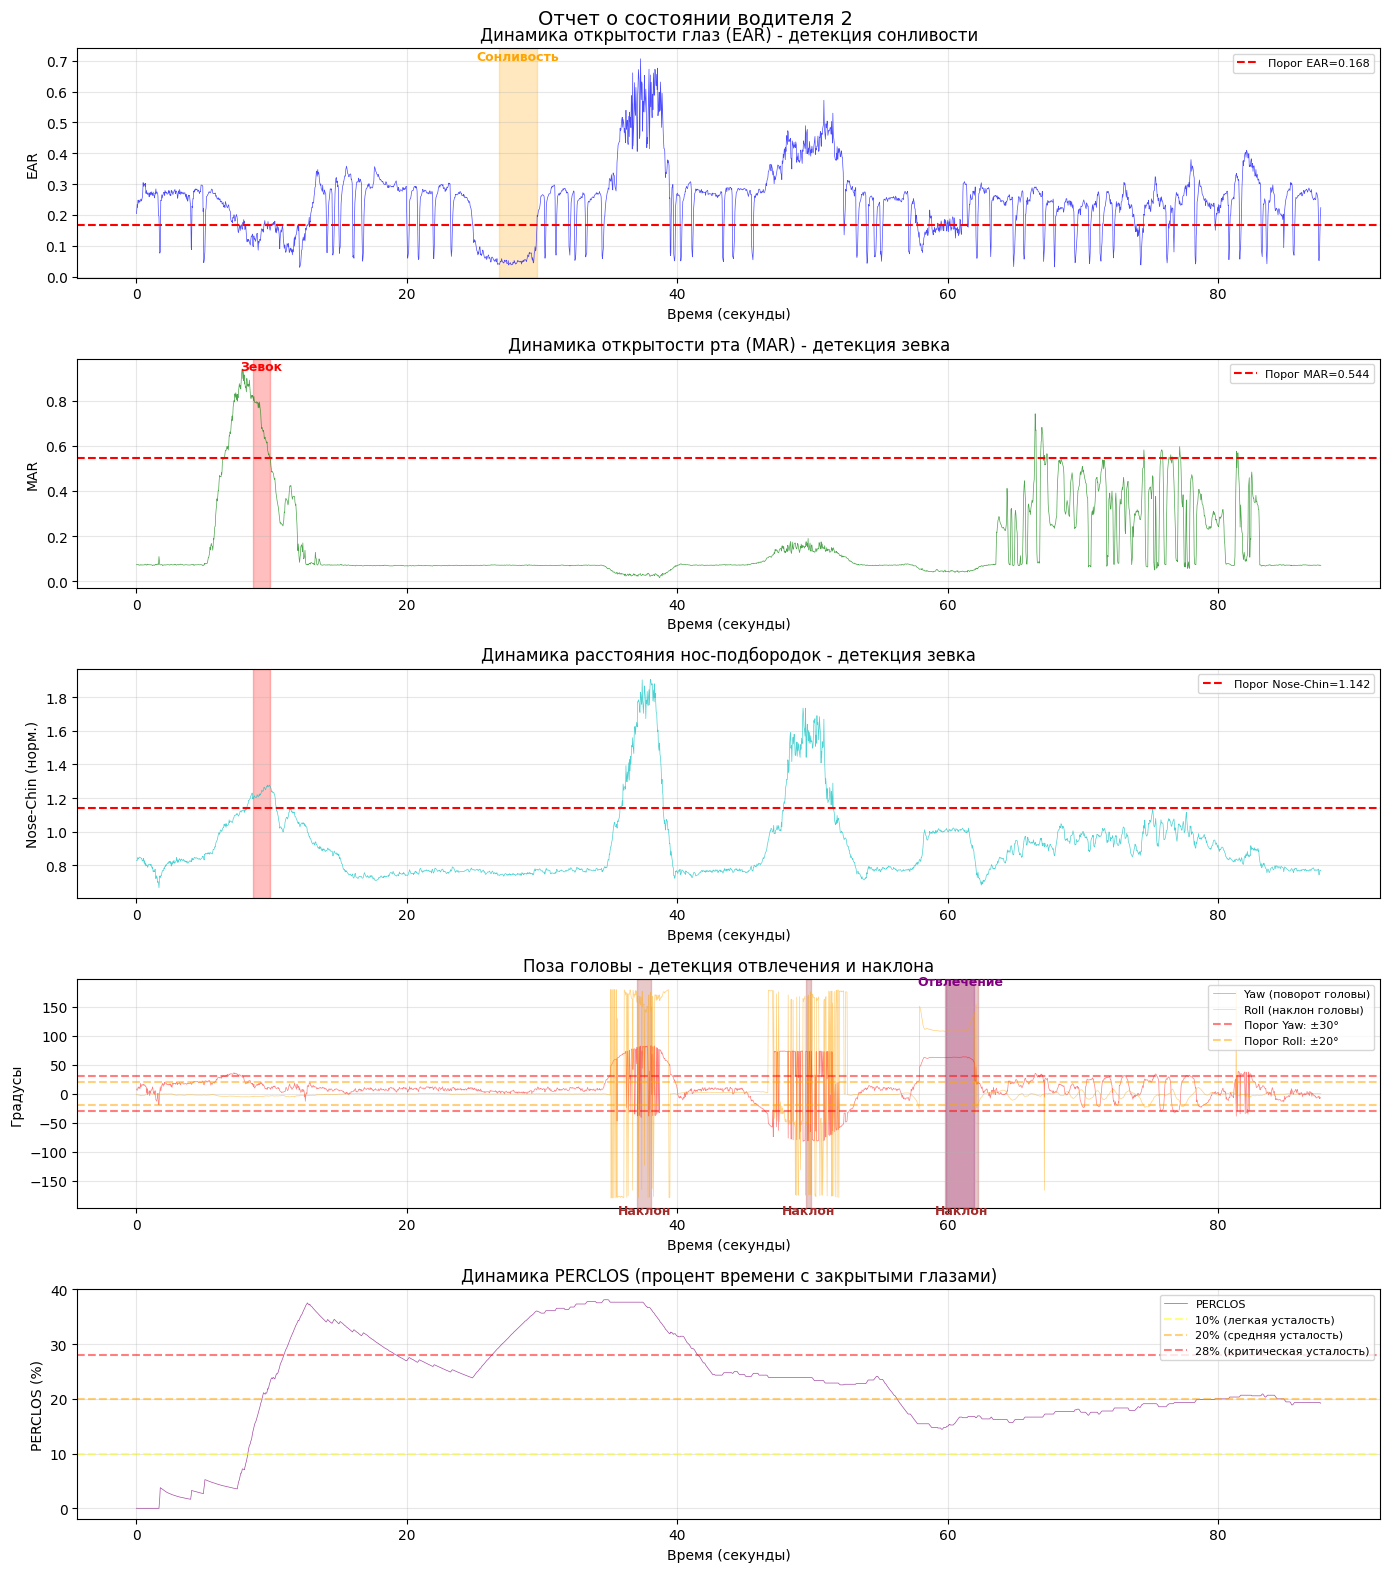

График сохранен: graph_2_2026-05-25.png
Завершение работы


In [139]:
# Создание экземпляра системы
system = FatigueMonitoringSystem()
print("Система готова к работе")


def main():
    """Главная функция приложения."""
    print("=" * 60)
    print("СИСТЕМА МОНИТОРИНГА СОСТОЯНИЯ ВОДИТЕЛЯ")
    print("=" * 60)
    print("\nГлавное меню:")
    print("1. Идентификация водителя")
    print("2. Запуск мониторинга")
    print("3. Генерация отчета")
    print("4. Выход")

    while True:
        choice = input("\nВыберите опцию (1-4): ").strip()

        if choice == '1':
            driver_id = system.identify_driver()
            if driver_id:
                print(f"Текущий водитель: {driver_id}")

        elif choice == '2':
            system.monitor()

        elif choice == '3':
            system.generate_report()

        elif choice == '4':
            print("Завершение работы")
            break

        else:
            print("Неверный выбор")


if __name__ == "__main__":
    main()

## 📋 Руководство по работе с системой мониторинга состояния водителя

### Общее описание системы

Система предназначена для неинвазивного мониторинга функционального состояния водителя в реальном времени на основе анализа видеопотока с веб-камеры. 

**Основные детектируемые состояния:**
- Зевок (признак усталости)
- Сонливость (длительное закрытие глаз)
- Отвлечение внимания (поворот головы)
- Наклон головы

### Принцип работы

Система использует библиотеку **MediaPipe** для детекции 468 ключевых точек лица. На основе этих точек вычисляются геометрические метрики:

| Метрика | Описание | Что детектирует |
|---------|----------|------------------|
| **EAR** (Eye Aspect Ratio) | Отношение высоты глаза к ширине | Сонливость (глаза закрыты) |
| **MAR** (Mouth Aspect Ratio) | Отношение высоты рта к ширине | Зевок (рот открыт) |
| **Nose-Chin** | Расстояние от кончика носа до подбородка | Опускание челюсти при зевке |
| **Yaw** | Поворот головы влево-вправо | Отвлечение внимания |
| **Roll** | Наклон головы к плечу | Наклон головы |

### Политопная детекция

Для устранения ложных срабатываний используется **политопный метод** — событие фиксируется только когда состояние сохраняется в течение определенного времени:

| Событие | Политопное окно | Что это означает |
|---------|-----------------|------------------|
| Зевок | 15 кадров (0.5 сек) | MAR и Nose-Chin выше порога в течение 0.5 сек |
| Сонливость | 60 кадров (2.0 сек) | EAR ниже порога в течение 2.0 сек |
| Отвлечение | 60 кадров (2.0 сек) | |Yaw| > 30° в течение 2.0 сек |
| Наклон головы | 60 кадров (2.0 сек) | |Roll| > 20° в течение 2.0 сек |

### Индивидуальная калибровка

Перед началом работы каждый водитель проходит **30-секундную калибровку**:
- Система запоминает базовые значения EAR, MAR, Nose-Chin в спокойном состоянии
- Индивидуальные пороги рассчитываются с использованием научных коэффициентов:
  - `K_MAR = 7.26`
  - `K_NOSE_CHIN = 1.38`

### Оценка критичности

Система оценивает текущее состояние водителя по 4 уровням:

| Уровень | Цвет рамки | Условие |
|---------|-----------|---------|
| **NORMAL** | Зеленый | Нет событий |
| **WARNING** | Желтый | Зевок ИЛИ отвлечение |
| **DANGER** | Оранжевый | Сонливость ИЛИ наклон |
| **CRITICAL** | Красный | PERCLOS ≥ 28% ИЛИ два события одновременно |

### PERCLOS (Percentage of Eye Closure)

Дополнительная метрика усталости — процент времени, в течение которого глаза были закрыты за последние 30 секунд:
- `normal`: PERCLOS < 10%
- `light`: 10% ≤ PERCLOS < 20%
- `medium`: 20% ≤ PERCLOS < 28%
- `critical`: PERCLOS ≥ 28%

### Результаты работы

После завершения мониторинга система генерирует:
1. **Текстовый отчет** — статистика событий, эффективность политопной фильтрации
2. **Графики** — динамика EAR, MAR, Nose-Chin, Yaw/Roll, PERCLOS
3. **База данных SQLite** — все данные сохраняются для последующего анализа

### Порядок запуска

1. **Запустите все ячейки** ноутбука последовательно
2. В меню выберите `1. Идентификация водителя`
3. Введите ID (например, `1`) и пройдите калибровку (30 сек)
4. Выберите `2. Запуск мониторинга` и имитируйте нужные состояния
5. Нажмите `q` для остановки
6. Выберите `3. Генерация отчета` для получения результатов

### Требования к окружению

- Камера направлена **анфас**
- Освещение **естественное**, без резких теней
- Рекомендуемое расстояние до камеры — **50-70 см**

ПРИЁМОЧНЫЕ ТЕСТЫ ДЛЯ СИСТЕМЫ МОНИТОРИНГА УСТАЛОСТИ

In [141]:
import unittest
import numpy as np
import pandas as pd
import json
import os
import tempfile
from collections import deque


class TestFormulas(unittest.TestCase):
    """Тесты математических формул."""

    def test_mar_dlib_style(self):
        """
        Тест формулы MAR Dlib-стиль с тремя вертикальными замерами.
        MAR = (|P80-P82| + |P13-P14| + |P312-P317|) / (3 * |P78-P308|)
        """
        def pt(x, y):
            return np.array([x, y])

        # Закрытый рот: вертикальные расстояния малы, горизонтальное велико
        v_left = np.linalg.norm(pt(0, 0) - pt(0, 1))
        v_center = np.linalg.norm(pt(0, 0) - pt(0, 2))
        v_right = np.linalg.norm(pt(0, 0) - pt(0, 1))
        horizontal = np.linalg.norm(pt(0, 0) - pt(100, 0))

        mar = (v_left + v_center + v_right) / (3.0 * horizontal)
        self.assertAlmostEqual(mar, 0.0133, delta=0.001)

    def test_ear_formula(self):
        """
        Тест формулы EAR.
        EAR = (|p2-p6| + |p3-p5|) / (2 * |p1-p4|)
        """
        pts = np.array([
            [0, 5],     # p1 (левый угол)
            [2, 4],     # p2 (верхнее веко, левая)
            [4, 4],     # p3 (верхнее веко, правая)
            [6, 5],     # p4 (правый угол)
            [4, 6],     # p5 (нижнее веко, правая)
            [2, 6]      # p6 (нижнее веко, левая)
        ], dtype=float)

        vertical = (np.linalg.norm(pts[1] - pts[5]) +
                    np.linalg.norm(pts[2] - pts[4]))
        horizontal = 2.0 * np.linalg.norm(pts[0] - pts[3])
        ear = vertical / (horizontal + 1e-6)

        # Открытый глаз: EAR ≈ 0.33
        self.assertAlmostEqual(ear, 0.33, delta=0.02)

    def test_nose_chin_formula(self):
        """
        Тест формулы расстояния нос-подбородок.
        D = |p_nose - p_chin| / |p_left_eye - p_right_eye|
        """
        nose = np.array([0, 0])
        chin = np.array([0, 100])
        left_eye = np.array([-50, -30])
        right_eye = np.array([50, -30])

        absolute = np.linalg.norm(nose - chin)
        face_w = np.linalg.norm(left_eye - right_eye)
        dist = absolute / face_w

        self.assertAlmostEqual(dist, 1.0, delta=0.01)

    def test_coefficient_k_calculation(self):
        """
        Тест расчета коэффициента K.
        K_MAR = P25(MAR_yawn) / Med(MAR_no_yawn)
        """
        yawn_values = np.array([0.5, 0.6, 0.7, 0.8, 0.9])
        no_yawn_values = np.array([0.04, 0.05, 0.06, 0.07, 0.08])

        yawn_p25 = np.percentile(yawn_values, 25)
        no_yawn_median = np.median(no_yawn_values)

        K_mar = yawn_p25 / no_yawn_median if no_yawn_median > 0 else 1.0

        self.assertGreater(K_mar, 1.0)
        self.assertAlmostEqual(K_mar, 10.0, delta=0.5)


class TestPolytopeLogic(unittest.TestCase):
    """Тесты логики политопной детекции."""

    def test_polytope_1d_above(self):
        """1D-политоп: все значения >= порога."""
        p = Polytope1D(window_size=5, threshold=30.0, mode='above')

        for val in [35, 32, 31, 33]:
            p.add_frame(val)
        self.assertFalse(p.check())

        p.add_frame(30)
        self.assertTrue(p.check())

        p.add_frame(25)
        self.assertFalse(p.check())

    def test_polytope_1d_below(self):
        """1D-политоп: все значения < порога."""
        p = Polytope1D(window_size=5, threshold=0.18, mode='below')

        for val in [0.10, 0.12, 0.15, 0.17, 0.16]:
            p.add_frame(val)
        self.assertTrue(p.check())

        p.add_frame(0.20)
        self.assertFalse(p.check())

    def test_polytope_2d_yawn(self):
        """2D-политоп: оба параметра >= порогов."""
        p = Polytope2D(window_size=5, mar_threshold=0.50,
                       nose_chin_threshold=1.10)

        for i in range(5):
            p.add_frame(0.55, 1.15)
        self.assertTrue(p.check())

        p.add_frame(0.45, 1.15)
        self.assertFalse(p.check())

    def test_polytope_2d_partial(self):
        """2D-политоп: только одно условие — нет срабатывания."""
        p = Polytope2D(window_size=5, mar_threshold=0.50,
                       nose_chin_threshold=1.20)

        for i in range(5):
            p.add_frame(0.55, 1.05)
        self.assertFalse(p.check())


class TestPERCLOS(unittest.TestCase):
    """Тесты калькулятора PERCLOS."""

    def test_perclos_range(self):
        """PERCLOS всегда в диапазоне 0-100%."""
        calc = PERCLOSCalculator(window_seconds=3, fps=10)
        calc.set_ear_threshold(0.20)

        # Открыты
        for _ in range(30):
            calc.add_frame(0.30)
        self.assertAlmostEqual(calc.calculate(), 0.0, delta=0.5)

        # Закрыты
        for _ in range(30):
            calc.add_frame(0.10)
        perclos = calc.calculate()
        self.assertAlmostEqual(perclos, 100.0, delta=0.5)
        self.assertLessEqual(perclos, 100.0)

    def test_perclos_scrolling(self):
        """Скользящее окно работает корректно."""
        calc = PERCLOSCalculator(window_seconds=3, fps=10)
        calc.set_ear_threshold(0.20)

        for _ in range(30):
            calc.add_frame(0.10)
        self.assertGreater(calc.calculate(), 90.0)

        for _ in range(30):
            calc.add_frame(0.30)
        self.assertAlmostEqual(calc.calculate(), 0.0, delta=0.5)

    def test_perclos_reset(self):
        """Сброс истории."""
        calc = PERCLOSCalculator(window_seconds=3, fps=10)
        calc.set_ear_threshold(0.20)

        for _ in range(30):
            calc.add_frame(0.10)
        self.assertGreater(calc.calculate(), 90.0)

        calc.reset()
        self.assertEqual(calc.calculate(), 0.0)


class TestCriticality(unittest.TestCase):
    """Тесты оценки критичности."""

    def setUp(self):
        self.eval = CriticalityEvaluator()

    def test_normal(self):
        """Нет событий — NORMAL."""
        level, messages = self.eval.evaluate(False, False, False, False, 'normal')
        self.assertEqual(level, 0)

    def test_yawn_warning(self):
        """Только зевок — WARNING."""
        level, messages = self.eval.evaluate(True, False, False, False, 'normal')
        self.assertEqual(level, 1)

    def test_drowsiness_danger(self):
        """Сонливость — DANGER."""
        level, messages = self.eval.evaluate(False, True, False, False, 'normal')
        self.assertEqual(level, 2)

    def test_yawn_drowsiness_critical(self):
        """Зевок + сонливость — CRITICAL."""
        level, messages = self.eval.evaluate(True, True, False, False, 'normal')
        self.assertEqual(level, 3)

    def test_perclos_critical(self):
        """PERCLOS critical — CRITICAL."""
        level, messages = self.eval.evaluate(False, False, False, False, 'critical')
        self.assertEqual(level, 3)


class TestDatabase(unittest.TestCase):
    """Тесты операций с базой данных."""

    def setUp(self):
        self.temp_dir = tempfile.mkdtemp()
        self.test_db = os.path.join(self.temp_dir, "test.db")
        self.original_path = config.DB_PATH
        config.DB_PATH = self.test_db
        self.db = DatabaseManager(config)

    def tearDown(self):
        config.DB_PATH = self.original_path
        import shutil
        shutil.rmtree(self.temp_dir)

    def test_profile_save_load(self):
        """Сохранение и загрузка профиля."""
        profile = {
            'driver_id': 'test_driver',
            'ear_baseline': 0.30,
            'mar_baseline': 0.07,
            'nose_chin_baseline': 0.85,
            'ear_threshold': 0.18,
            'mar_threshold': 0.51,
            'nose_chin_threshold': 1.17,
            'calibration_date': '2026-05-06'
        }
        self.db.save_driver_profile(profile)
        loaded = self.db.get_driver_profile('test_driver')

        self.assertIsNotNone(loaded)
        self.assertAlmostEqual(loaded['mar_threshold'], 0.51, delta=0.01)

    def test_monitoring_save(self):
        """Сохранение данных мониторинга с флагами событий."""
        profile = {
            'driver_id': 'driver_1',
            'ear_baseline': 0.30, 'mar_baseline': 0.07,
            'nose_chin_baseline': 0.85, 'ear_threshold': 0.18,
            'mar_threshold': 0.51, 'nose_chin_threshold': 1.17,
            'calibration_date': '2026-05-06'
        }
        self.db.save_driver_profile(profile)

        self.db.save_monitoring_data(
            driver_id='driver_1',
            metrics={'ear': 0.25, 'mar': 0.07, 'nose_chin': 0.85,
                     'yaw': 5.0, 'roll': 2.0},
            perclos_value=15.5, fatigue_level='light',
            criticality_level=1,
            yawn_detected=False, distraction_detected=False,
            roll_detected=False, drowsiness_detected=False
        )

        conn = __import__('sqlite3').connect(self.test_db)
        cursor = conn.cursor()
        cursor.execute("SELECT COUNT(*) FROM monitoring_data")
        count = cursor.fetchone()[0]
        conn.close()

        self.assertEqual(count, 1)


def run_acceptance_tests():
    """Запуск всех приемочных тестов."""
    print("=" * 60)
    print("ЗАПУСК ПРИЕМОЧНЫХ ТЕСТОВ")
    print("=" * 60)

    test_suite = unittest.TestSuite()
    test_suite.addTest(unittest.TestLoader().loadTestsFromTestCase(TestFormulas))
    test_suite.addTest(unittest.TestLoader().loadTestsFromTestCase(TestPolytopeLogic))
    test_suite.addTest(unittest.TestLoader().loadTestsFromTestCase(TestPERCLOS))
    test_suite.addTest(unittest.TestLoader().loadTestsFromTestCase(TestCriticality))
    test_suite.addTest(unittest.TestLoader().loadTestsFromTestCase(TestDatabase))

    runner = unittest.TextTestRunner(verbosity=2)
    result = runner.run(test_suite)

    print("\n" + "=" * 60)
    print("ИТОГИ ТЕСТИРОВАНИЯ")
    print("=" * 60)
    print(f"Всего тестов: {result.testsRun}")
    passed = result.testsRun - len(result.failures) - len(result.errors)
    print(f"Пройдено: {passed}")
    print(f"Провалено: {len(result.failures)}")
    print(f"Ошибок: {len(result.errors)}")

    if result.wasSuccessful():
        print("\nВсе тесты пройдены успешно.")
    else:
        print("\nНекоторые тесты не пройдены.")

    return result.wasSuccessful()


if __name__ == "__main__":
    success = run_acceptance_tests()

test_coefficient_k_calculation (__main__.TestFormulas.test_coefficient_k_calculation)
Тест расчета коэффициента K. ... ok
test_ear_formula (__main__.TestFormulas.test_ear_formula)
Тест формулы EAR. ... ok
test_mar_dlib_style (__main__.TestFormulas.test_mar_dlib_style)
Тест формулы MAR Dlib-стиль с тремя вертикальными замерами. ... ok
test_nose_chin_formula (__main__.TestFormulas.test_nose_chin_formula)
Тест формулы расстояния нос-подбородок. ... ok
test_polytope_1d_above (__main__.TestPolytopeLogic.test_polytope_1d_above)
1D-политоп: все значения >= порога. ... ok
test_polytope_1d_below (__main__.TestPolytopeLogic.test_polytope_1d_below)
1D-политоп: все значения < порога. ... ok
test_polytope_2d_partial (__main__.TestPolytopeLogic.test_polytope_2d_partial)
2D-политоп: только одно условие — нет срабатывания. ... ok
test_polytope_2d_yawn (__main__.TestPolytopeLogic.test_polytope_2d_yawn)
2D-политоп: оба параметра >= порогов. ... ok
test_perclos_range (__main__.TestPERCLOS.test_perclos_ra

ok
test_profile_save_load (__main__.TestDatabase.test_profile_save_load)
Сохранение и загрузка профиля. ... ok

----------------------------------------------------------------------
Ran 18 tests in 0.090s

OK


ЗАПУСК ПРИЕМОЧНЫХ ТЕСТОВ
База данных инициализирована: C:\Users\volkova.nv\AppData\Local\Temp\tmpihtxwco1\test.db
База данных инициализирована: C:\Users\volkova.nv\AppData\Local\Temp\tmpfp_c0yjf\test.db

ИТОГИ ТЕСТИРОВАНИЯ
Всего тестов: 18
Пройдено: 18
Провалено: 0
Ошибок: 0

Все тесты пройдены успешно.
